# Linear Regression Baseline — Heat Pump Load Forecasting

Simple baseline: aggregate 5-minute telemetry to daily averages per device, train linear regression to predict daily avg x2, then generate monthly predictions for submission.

In [1]:
import pandas as pd
import numpy as np


DATA_PATH = "data/data.csv"
CHUNK_SIZE = 500_000

FEATURE_COLS = [
    "t1", "t2", "t3", "t4", "t5", "t6", "t7",
    "t8", "t9", "t10", "t11", "t12", "t13",
    "x1", "x3", "deviceType",
]
TARGET_COL = "x2"
ALL_COLS = FEATURE_COLS + [TARGET_COL]

print("Imports OK")

Imports OK


## Cell 2 — Chunked load & daily aggregation (train only)

In [2]:
train_sums = []
train_counts = []

for i, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, low_memory=False)):
    # Filter train only
    chunk = chunk[chunk["period"] == "train"].copy()
    if len(chunk) == 0:
        continue

    # Parse timedate and extract date
    chunk["timedate"] = pd.to_datetime(
        chunk["timedate"].str.replace(" UTC", "", regex=False), utc=True
    )
    chunk["date"] = chunk["timedate"].dt.date

    # Only keep columns we need
    cols_present = [c for c in ALL_COLS if c in chunk.columns]
    grp = chunk.groupby(["deviceId", "date"])[cols_present]

    train_sums.append(grp.sum())
    train_counts.append(grp.count())

    if (i + 1) % 5 == 0:
        print(f"  processed {(i + 1) * CHUNK_SIZE:,} rows...")

print("Combining partial aggregations...")
total_sum = pd.concat(train_sums).groupby(level=["deviceId", "date"]).sum()
total_count = pd.concat(train_counts).groupby(level=["deviceId", "date"]).sum()
daily_train = (total_sum / total_count).reset_index()

del train_sums, train_counts, total_sum, total_count

print(f"Daily train aggregation complete: {daily_train.shape}")

  processed 2,500,000 rows...
  processed 5,000,000 rows...
  processed 7,500,000 rows...
  processed 10,000,000 rows...
  processed 12,500,000 rows...
  processed 15,000,000 rows...
  processed 17,500,000 rows...
  processed 20,000,000 rows...
  processed 22,500,000 rows...
  processed 25,000,000 rows...
  processed 27,500,000 rows...
  processed 30,000,000 rows...
  processed 32,500,000 rows...
  processed 35,000,000 rows...
  processed 37,500,000 rows...
  processed 40,000,000 rows...
  processed 42,500,000 rows...
  processed 45,000,000 rows...
  processed 47,500,000 rows...
  processed 50,000,000 rows...
  processed 52,500,000 rows...
  processed 55,000,000 rows...
  processed 57,500,000 rows...
  processed 60,000,000 rows...
  processed 62,500,000 rows...
Combining partial aggregations...
Daily train aggregation complete: (122310, 19)


# rolling windows 7 overlap 2

In [118]:
# import pandas as pd
#
# # --- PHASE 1: STANDARD DAILY AGGREGATION (Your original logic) ---
# train_sums = []
# train_counts = []
#
# for i, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, low_memory=False)):
#     chunk = chunk[chunk["period"] == "train"].copy()
#     if len(chunk) == 0: continue
#
#     chunk["timedate"] = pd.to_datetime(chunk["timedate"].str.replace(" UTC", "", regex=False), utc=True)
#     chunk["date"] = chunk["timedate"].dt.date
#
#     cols_present = [c for c in ALL_COLS if c in chunk.columns]
#     grp = chunk.groupby(["deviceId", "date"])[cols_present]
#
#     train_sums.append(grp.sum())
#     train_counts.append(grp.count())
#
#     if (i + 1) % 5 == 0:
#         print(f"  processed {(i + 1) * CHUNK_SIZE:,} rows...")
#
# total_sum = pd.concat(train_sums).groupby(level=["deviceId", "date"]).sum()
# total_count = pd.concat(train_counts).groupby(level=["deviceId", "date"]).sum()
# daily_train = (total_sum / total_count).reset_index()
#
# # --- PHASE 2: OVERLAPPING WEEKLY AGGREGATION ---
# print("Creating rolling weekly windows with 2-day step...")
#
# # Ensure date is a datetime object for rolling operations
# daily_train["date"] = pd.to_datetime(daily_train["date"])
# daily_train = daily_train.sort_values(["deviceId", "date"])
#
# weekly_dfs = []
#
# for device, group in daily_train.groupby("deviceId"):
#     # Create 7-day rolling mean
#     # min_periods=7 ensures we only get full weeks
#     rolling = (
#         group.set_index("date")[ALL_COLS]
#         .rolling(window='7D', min_periods=7)
#         .mean()
#     )
#
#     # Apply the 2-day step (stride)
#     # This keeps every 2nd day from the rolling results
#     stepped = rolling.iloc[::2].reset_index()
#     stepped["deviceId"] = device
#     weekly_dfs.append(stepped)
#
# # Combine and clean up
# daily_train = pd.concat(weekly_dfs).dropna().reset_index(drop=True)
#
# del train_sums, train_counts, total_sum, total_count, weekly_dfs
#
# print(f"Overlapping weekly aggregation complete: {daily_train.shape}")

  processed 2,500,000 rows...
  processed 5,000,000 rows...
  processed 7,500,000 rows...
  processed 10,000,000 rows...
  processed 12,500,000 rows...
  processed 15,000,000 rows...
  processed 17,500,000 rows...
  processed 20,000,000 rows...
  processed 22,500,000 rows...
  processed 25,000,000 rows...
  processed 27,500,000 rows...
  processed 30,000,000 rows...
  processed 32,500,000 rows...
  processed 35,000,000 rows...
  processed 37,500,000 rows...
  processed 40,000,000 rows...
  processed 42,500,000 rows...
  processed 45,000,000 rows...
  processed 47,500,000 rows...
  processed 50,000,000 rows...
  processed 52,500,000 rows...
  processed 55,000,000 rows...
  processed 57,500,000 rows...
  processed 60,000,000 rows...
  processed 62,500,000 rows...
Creating rolling weekly windows with 2-day step...
Overlapping weekly aggregation complete: (58426, 19)


In [119]:
daily_train.describe().T

,count,mean,min,25%,50%,75%,max,std
date,58426,2025-01-17 04:26:36,2024-10-07 00:00:00,2024-11-26 00:00:00,2025-01-17 00:00:00,2025-03-10 00:00:00,2025-04-30 00:00:00,NaN
t1,58426.0,0.279558,0.0,0.26248,0.27498,0.295287,1.0,0.02997
t2,58426.0,0.045347,0.03,0.04001,0.045773,0.05,0.13,0.005714
t3,58426.0,0.004638,0.0,0.0,0.0,0.0,1.0,0.062813
t4,58426.0,0.392123,0.0,0.365769,0.388859,0.417578,0.982128,0.044781
t5,58426.0,0.435922,0.253735,0.416463,0.436613,0.457693,0.536746,0.035181
t6,58426.0,0.415923,0.251186,0.399627,0.418432,0.435898,0.50755,0.030516
t7,58426.0,0.210448,0.118398,0.203215,0.208146,0.213168,0.45,0.034434
t8,58426.0,0.514692,0.437431,0.50126,0.515157,0.528472,0.575533,0.019961
t9,58426.0,0.391883,0.0,0.366498,0.388338,0.407851,0.9,0.067874


## Cell 3 — Inspect daily aggregated dataframe

In [120]:
print(f"Shape: {daily_train.shape}")
print(f"\nNull counts:")
print(daily_train.isnull().sum())
print(f"\nUnique (deviceId, date) pairs: {daily_train[['deviceId', 'date']].drop_duplicates().shape[0]}")
daily_train.head()

Shape: (58426, 19)

Null counts:
date          0
t1            0
t2            0
t3            0
t4            0
t5            0
t6            0
t7            0
t8            0
t9            0
t10           0
t11           0
t12           0
t13           0
x1            0
x3            0
deviceType    0
x2            0
deviceId      0
dtype: int64

Unique (deviceId, date) pairs: 58426


,date,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11,t12,t13,x1,x3,deviceType,x2,deviceId
0,2024-10-07,0.304804,0.049692,0.0,0.391870,0.448942,0.436739,0.207250,0.516067,0.388361,0.210397,0.209736,0.068090,0.069440,0.0,8.0,19.0,0.108521,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
1,2024-10-09,0.312013,0.049692,0.0,0.387893,0.441180,0.429692,0.207237,0.514454,0.380036,0.210891,0.210309,0.066828,0.068040,0.0,8.0,19.0,0.091392,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
2,2024-10-11,0.317751,0.050000,0.0,0.382560,0.431879,0.421411,0.207418,0.510510,0.371416,0.211164,0.210443,0.065237,0.066507,0.0,8.0,19.0,0.074175,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
3,2024-10-13,0.318445,0.050000,0.0,0.381761,0.429707,0.420170,0.206857,0.507271,0.369903,0.211213,0.210364,0.065088,0.066378,0.0,8.0,19.0,0.068937,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
4,2024-10-15,0.312937,0.048963,0.0,0.390848,0.439524,0.429241,0.206642,0.509603,0.379821,0.210615,0.209836,0.066458,0.067872,0.0,8.0,19.0,0.095507,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...


## Cell 4 — Train Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_cols_present = [c for c in FEATURE_COLS if c in daily_train.columns]

In [127]:
feature_cols_present = [
 't1',
 't2',
 't3',
 't4',
 't5',
 't6',
 't7',
 't8',
 't9',
 't10',
 't11',
 # 't12',
 # 't13',
 # 'x1',
 'x3',
 'deviceType'
]

In [128]:
train_clean = daily_train.dropna(subset=feature_cols_present + [TARGET_COL])
X_train = train_clean[feature_cols_present].values
y_train = train_clean[TARGET_COL].values

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
print(f"Train MAE (in-sample): {train_mae:.6f}")

print("\nCoefficients:")
for feat, coef in zip(feature_cols_present, model.coef_):
    print(f"  {feat:>12s}: {coef:.6f}")
print(f"  {'intercept':>12s}: {model.intercept_:.6f}")

Train MAE (in-sample): 0.054600

Coefficients:
            t1: -0.154303
            t2: -0.764015
            t3: 0.019182
            t4: 0.476151
            t5: 2.910791
            t6: -2.899903
            t7: 0.269671
            t8: 1.426859
            t9: 0.079182
           t10: -3.548198
           t11: -4.698493
            x3: 0.001433
    deviceType: 0.017284
     intercept: 0.630319


# Linear

In [129]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Dictionary to store a unique model for each device type
models_per_type = {}
train_info = []

unique_types = daily_train['deviceType'].unique()

for d_type in unique_types:
    # Filter data for this specific device type
    df_type = daily_train[daily_train['deviceType'] == d_type].dropna(subset=feature_cols_present + [TARGET_COL])

    if len(df_type) < 5:  # Minimum samples check
        print(f"Skipping Device Type {d_type}: Not enough data.")
        continue

    X_t = df_type[feature_cols_present].values
    y_t = df_type[TARGET_COL].values

    # Initialize and train standard Linear Regression
    model = LinearRegression()
    model.fit(X_t, y_t)

    # Store the model object
    models_per_type[d_type] = model

    # Calculate in-sample MAE for reporting
    y_p = model.predict(X_t)
    mae = mean_absolute_error(y_t, y_p)
    train_info.append({'Type': d_type, 'MAE': mae, 'Samples': len(df_type)})

# Display summary
print(f"{'Device Type':<15} | {'Train MAE':<12} | {'Sample Count'}")
print("-" * 45)
for info in train_info:
    print(f"{info['Type']:<15} | {info['MAE']:<12.6f} | {info['Samples']}")

Device Type     | Train MAE    | Sample Count
---------------------------------------------
19.0            | 0.090654     | 35154
11.0            | 0.019704     | 74912
7.0             | 0.008853     | 12244


# Quadratic

In [130]:
from sklearn.linear_model import LinearRegression, QuantileRegressor, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

# Dictionary to store a unique quadratic model for each device type
models_per_type = {}
train_info = []

unique_types = daily_train['deviceType'].unique()

for d_type in unique_types:
    # Filter data for this specific device type
    df_type = daily_train[daily_train['deviceType'] == d_type].dropna(subset=feature_cols_present + [TARGET_COL])

    # Quadratic models have more coefficients, so we increase the minimum sample check
    if len(df_type) < 15:
        print(f"Skipping Device Type {d_type}: Not enough data for quadratic fit.")
        continue

    X_t = df_type[feature_cols_present].values
    y_t = df_type[TARGET_COL].values

    # Create a Pipeline:
    # 1. PolynomialFeatures(degree=2) creates [x, x^2, x_i*x_j]
    # 2. LinearRegression() fits the coefficients to those terms
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('linear', LinearRegression())
    ])

    model.fit(X_t, y_t)

    # Store the Pipeline object
    models_per_type[d_type] = model

    # Calculate in-sample MAE
    y_p = model.predict(X_t)
    mae = mean_absolute_error(y_t, y_p)
    train_info.append({'Type': d_type, 'MAE': mae, 'Samples': len(df_type)})

# Display summary
print(f"{'Device Type':<15} | {'Train MAE':<12} | {'Sample Count'}")
print("-" * 45)
for info in train_info:
    print(f"{info['Type']:<15} | {info['MAE']:<12.6f} | {info['Samples']}")

Device Type     | Train MAE    | Sample Count
---------------------------------------------
19.0            | 0.061932     | 35154
11.0            | 0.013979     | 74912
7.0             | 0.006212     | 12244


In [117]:
import pandas as pd

coef_reports = []

for d_type, pipeline in models_per_type.items():
    # 1. Extract the feature names from the 'poly' step
    # This handles degree 1, 2, or 3 automatically
    poly_step = pipeline.named_steps['poly']
    feature_names = poly_step.get_feature_names_out(feature_cols_present)

    # 2. Extract coefficients from the 'linear' step
    # Works for LinearRegression, SGDRegressor, or QuantileRegressor
    coefs = pipeline.named_steps['linear'].coef_
    intercept = pipeline.named_steps['linear'].intercept_

    # 3. Create a dictionary for this device type
    device_coefs = {'DeviceType': d_type, 'Intercept': intercept}
    for name, val in zip(feature_names, coefs):
        device_coefs[name] = val

    coef_reports.append(device_coefs)

# 4. Create DataFrame and display nicely
coef_df = pd.DataFrame(coef_reports).set_index('DeviceType')

print("Model Coefficients per Device Type:")
# Using a gradient to highlight which features push load UP (red) or DOWN (blue)
display(coef_df.style.background_gradient(cmap='coolwarm', axis=1).format(precision=4))

Model Coefficients per Device Type:


In [ ]:
train_clean["deviceType"].value_counts()

In [118]:
# import optuna
# from sklearn.linear_model import Lasso
# from sklearn.model_selection import cross_val_score
#
# lasso_models = {}
# lasso_best_alphas = {}
#
# for d_type in daily_train['deviceType'].unique():
#     # Filter data for this device
#     df_type = daily_train[daily_train['deviceType'] == d_type].dropna(subset=feature_cols_present + [TARGET_COL])
#     if len(df_type) < 20: continue # Skip if data is too sparse for CV
#
#     X_t, y_t = df_type[feature_cols_present].values, df_type[TARGET_COL].values
#
#     def objective(trial):
#         # Search alpha on a log scale
#         alpha = trial.suggest_float("alpha", 1e-5, 10.0, log=True)
#         # We increase max_iter to ensure Lasso converges with small alphas
#         model = Lasso(alpha=alpha, max_iter=5000, random_state=42)
#         model.fit(X_t, y_t)
#         # scoring is 'neg_mean_absolute_error' because we want to minimize MAE
#         preds = model.predict(X_t)
#         return mean_squared_error(y_t, preds)
#
#     print(f"Optimizing Lasso for Device: {d_type}")
#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=30, show_progress_bar=False)
#
#     # Train the final Lasso model for this device using the best alpha
#     best_alpha = study.best_params['alpha']
#     final_model = Lasso(alpha=best_alpha, max_iter=5000).fit(X_t, y_t)
#
#     lasso_models[d_type] = final_model
#     lasso_best_alphas[d_type] = best_alpha
#
# print("\nBest Lasso Alphas found:", lasso_best_alphas)

In [136]:
import optuna
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

lasso_models = {}
lasso_best_alphas = {}

# Set the degree you want (2 for quadratic, 3 for cubic)
POLY_DEGREE = 3

for d_type in daily_train['deviceType'].unique():
    # Filter data for this device
    df_type = daily_train[daily_train['deviceType'] == d_type].dropna(subset=feature_cols_present + [TARGET_COL])

    # Polynomial features significantly increase the number of columns.
    # We increase the minimum sample check to avoid overfitting.
    if len(df_type) < 30:
        print(f"Skipping Device Type {d_type}: Not enough data for Poly-Lasso.")
        continue

    X_t, y_t = df_type[feature_cols_present].values, df_type[TARGET_COL].values

    def objective(trial):
        # 1. Suggest Alpha
        alpha = trial.suggest_float("alpha", 1e-5, 5.0, log=True)

        # 2. Create Pipeline
        # We MUST scale after generating polynomial features because x^2 grows much faster than x
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=10000, random_state=42))
        ])

        # 3. Fit and Evaluate (using the "whole train" approach you requested earlier)
        model.fit(X_t, y_t)
        preds = model.predict(X_t)
        return mean_squared_error(y_t, preds)

    print(f"Optimizing Poly-Lasso (Degree {POLY_DEGREE}) for Device: {d_type}")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=3, show_progress_bar=False)

    # Train the final model with best params
    best_alpha = study.best_params['alpha']
    final_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=best_alpha, max_iter=10000, random_state=42))
    ])
    final_pipeline.fit(X_t, y_t)

    lasso_models[d_type] = final_pipeline
    lasso_best_alphas[d_type] = best_alpha

print("\nOptimization Complete.")
print("Best Lasso Alphas found:", lasso_best_alphas)

[I 2026-03-15 04:09:54,987] A new study created in memory with name: no-name-1707cb1e-5537-4a6c-9315-faf8d6e27ff0


Optimizing Poly-Lasso (Degree 3) for Device: 19.0


/Users/jakubkasperski/PycharmProjects/Personal/Rage-Against-Machine-Learning/Task3/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.939e+01, tolerance: 1.539e-01
  model = cd_fast.enet_coordinate_descent(
[I 2026-03-15 04:10:31,594] Trial 0 finished with value: 0.008690117526646501 and parameters: {'alpha': 1.2448791970906144e-05}. Best is trial 0 with value: 0.008690117526646501.
[I 2026-03-15 04:10:32,458] Trial 1 finished with value: 0.01463350205948888 and parameters: {'alpha': 0.03261886777159258}. Best is trial 0 with value: 0.008690117526646501.
[I 2026-03-15 04:10:32,668] Trial 2 finished with value: 0.04377583579235927 and parameters: {'alpha': 1.3630082606620773}. Best is trial 0 with value: 0.008690117526646501.
/Users/jakubkasperski/PycharmProjects/Persona

Optimizing Poly-Lasso (Degree 3) for Device: 11.0


[I 2026-03-15 04:11:09,783] Trial 0 finished with value: 0.001662652218306518 and parameters: {'alpha': 0.02521462926932158}. Best is trial 0 with value: 0.001662652218306518.
/Users/jakubkasperski/PycharmProjects/Personal/Rage-Against-Machine-Learning/Task3/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.180e+00, tolerance: 3.912e-02
  model = cd_fast.enet_coordinate_descent(
[I 2026-03-15 04:12:19,300] Trial 1 finished with value: 0.0004896242793250604 and parameters: {'alpha': 1.1284884857415153e-05}. Best is trial 1 with value: 0.0004896242793250604.
[I 2026-03-15 04:12:19,759] Trial 2 finished with value: 0.005222218398035203 and parameters: {'alpha': 0.6473744395437796}. Best is trial 1 with value: 0.0004896242793250604.
/Users/jakubkasperski/PycharmProjects/Pe

Optimizing Poly-Lasso (Degree 3) for Device: 7.0


[I 2026-03-15 04:13:33,017] Trial 1 finished with value: 0.00015729783415999562 and parameters: {'alpha': 6.508664715343286e-05}. Best is trial 1 with value: 0.00015729783415999562.
[I 2026-03-15 04:13:34,085] Trial 2 finished with value: 0.00017662176721886457 and parameters: {'alpha': 0.0006782698681909604}. Best is trial 1 with value: 0.00015729783415999562.



Optimization Complete.
Best Lasso Alphas found: {np.float64(19.0): 1.2448791970906144e-05, np.float64(11.0): 1.1284884857415153e-05, np.float64(7.0): 6.508664715343286e-05}


In [120]:
# from sklearn.linear_model import Ridge
#
# ridge_models = {}
# ridge_best_alphas = {}
#
# for d_type in daily_train['deviceType'].unique():
#     df_type = daily_train[daily_train['deviceType'] == d_type].dropna(subset=feature_cols_present + [TARGET_COL])
#     if len(df_type) < 20: continue
#
#     X_t, y_t = df_type[feature_cols_present].values, df_type[TARGET_COL].values
#
#     def objective(trial):
#         alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
#         model = Ridge(alpha=alpha, random_state=42)
#         model.fit(X_t, y_t)
#         preds = model.predict(X_t)
#         return mean_squared_error(y_t, preds)
#
#     print(f"Optimizing Ridge for Device: {d_type}")
#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=30, show_progress_bar=False)
#
#     best_alpha = study.best_params['alpha']
#     ridge_models[d_type] = Ridge(alpha=best_alpha).fit(X_t, y_t)
#     ridge_best_alphas[d_type] = best_alpha
#
# print("\nBest Ridge Alphas found:", ridge_best_alphas)

In [135]:
import optuna
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

ridge_models = {}
ridge_best_alphas = {}

# Set the degree (2 for quadratic, 3 for cubic)

for d_type in daily_train['deviceType'].unique():
    # Filter data for this device
    df_type = daily_train[daily_train['deviceType'] == d_type].dropna(subset=feature_cols_present + [TARGET_COL])

    # Ridge is more stable than Lasso, but poly features still need decent sample sizes
    if len(df_type) < 20:
        print(f"Skipping Device Type {d_type}: Not enough data for Poly-Ridge.")
        continue

    X_t, y_t = df_type[feature_cols_present].values, df_type[TARGET_COL].values

    def objective(trial):
        # 1. Suggest Alpha (Ridge often uses larger alpha ranges than Lasso)
        alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)

        # 2. Create Pipeline
        # Scaler is still mandatory for Ridge to ensure alpha treats all terms fairly
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha, random_state=42))
        ])

        # 3. Fit and Evaluate on whole train set
        model.fit(X_t, y_t)
        preds = model.predict(X_t)
        return mean_squared_error(y_t, preds)

    print(f"Optimizing Poly-Ridge (Degree {POLY_DEGREE}) for Device: {d_type}")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=30, show_progress_bar=False)

    # Train final Ridge model with best params
    best_alpha = study.best_params['alpha']
    final_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=best_alpha, random_state=42))
    ])
    final_pipeline.fit(X_t, y_t)

    ridge_models[d_type] = final_pipeline
    ridge_best_alphas[d_type] = best_alpha

print("\nOptimization Complete.")
print("Best Ridge Alphas found:", ridge_best_alphas)

[I 2026-03-15 04:09:31,532] A new study created in memory with name: no-name-9fef0ee5-0557-420d-9822-95738e5bb18e


Optimizing Poly-Ridge (Degree 3) for Device: 19.0


[I 2026-03-15 04:09:31,754] Trial 0 finished with value: 0.007356964613619896 and parameters: {'alpha': 0.006746567846865674}. Best is trial 0 with value: 0.007356964613619896.
[I 2026-03-15 04:09:31,958] Trial 1 finished with value: 0.00933397528398735 and parameters: {'alpha': 41.3259355604651}. Best is trial 0 with value: 0.007356964613619896.
[I 2026-03-15 04:09:32,155] Trial 2 finished with value: 0.009315947902931596 and parameters: {'alpha': 39.29081911353372}. Best is trial 0 with value: 0.007356964613619896.
[I 2026-03-15 04:09:32,393] Trial 3 finished with value: 0.007036769152836041 and parameters: {'alpha': 0.001072450944442476}. Best is trial 3 with value: 0.007036769152836041.
[I 2026-03-15 04:09:32,627] Trial 4 finished with value: 0.00702571488239427 and parameters: {'alpha': 0.001002475810975354}. Best is trial 4 with value: 0.00702571488239427.
[I 2026-03-15 04:09:32,884] Trial 5 finished with value: 0.009059506464434477 and parameters: {'alpha': 18.82853909077775}. B

Optimizing Poly-Ridge (Degree 3) for Device: 11.0


[I 2026-03-15 04:09:38,724] Trial 0 finished with value: 0.00041669296594776045 and parameters: {'alpha': 0.23530926216804243}. Best is trial 0 with value: 0.00041669296594776045.
[I 2026-03-15 04:09:39,238] Trial 1 finished with value: 0.0003884603002989548 and parameters: {'alpha': 0.0012335830177284855}. Best is trial 1 with value: 0.0003884603002989548.
[I 2026-03-15 04:09:39,701] Trial 2 finished with value: 0.0003969442969689361 and parameters: {'alpha': 0.011416748941774236}. Best is trial 1 with value: 0.0003884603002989548.
[I 2026-03-15 04:09:40,214] Trial 3 finished with value: 0.0003929063417056403 and parameters: {'alpha': 0.004711625058352248}. Best is trial 1 with value: 0.0003884603002989548.
[I 2026-03-15 04:09:40,804] Trial 4 finished with value: 0.00039844604496751414 and parameters: {'alpha': 0.015317386851807576}. Best is trial 1 with value: 0.0003884603002989548.
[I 2026-03-15 04:09:41,343] Trial 5 finished with value: 0.00039554968555036504 and parameters: {'alph

Optimizing Poly-Ridge (Degree 3) for Device: 7.0


[I 2026-03-15 04:09:53,062] Trial 2 finished with value: 0.00011655234358727032 and parameters: {'alpha': 0.3427757837415007}. Best is trial 2 with value: 0.00011655234358727032.
[I 2026-03-15 04:09:53,131] Trial 3 finished with value: 0.00010983278935418125 and parameters: {'alpha': 0.08363641886715922}. Best is trial 3 with value: 0.00010983278935418125.
[I 2026-03-15 04:09:53,199] Trial 4 finished with value: 0.00011049163943643194 and parameters: {'alpha': 0.09757731797972}. Best is trial 3 with value: 0.00010983278935418125.
[I 2026-03-15 04:09:53,267] Trial 5 finished with value: 0.00013404102036099994 and parameters: {'alpha': 7.80606480280719}. Best is trial 3 with value: 0.00010983278935418125.
[I 2026-03-15 04:09:53,336] Trial 6 finished with value: 9.716847299653971e-05 and parameters: {'alpha': 0.0037071193318054213}. Best is trial 6 with value: 9.716847299653971e-05.
[I 2026-03-15 04:09:53,405] Trial 7 finished with value: 9.596500366141299e-05 and parameters: {'alpha': 0.


Optimization Complete.
Best Ridge Alphas found: {np.float64(19.0): 0.001002475810975354, np.float64(11.0): 0.0010651420981211016, np.float64(7.0): 0.0010099317025175421}


In [137]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_comparison = []

# Get the list of device types that have both models
device_types = set(lasso_models.keys()).intersection(set(ridge_models.keys()))

for d_type in device_types:
    # Filter train data for this device type
    train_subset = daily_train[daily_train['deviceType'] == d_type].dropna(subset=feature_cols_present + [TARGET_COL])

    if len(train_subset) == 0:
        continue

    X_t = train_subset[feature_cols_present].values
    y_t = train_subset[TARGET_COL].values

    # Lasso In-Sample Metrics
    l_pred = lasso_models[d_type].predict(X_t)
    l_mae = mean_absolute_error(y_t, l_pred)
    l_mse = mean_squared_error(y_t, l_pred)

    # Ridge In-Sample Metrics
    r_pred = ridge_models[d_type].predict(X_t)
    r_mae = mean_absolute_error(y_t, r_pred)
    r_mse = mean_squared_error(y_t, r_pred)

    # normal models
    n_pred = models_per_type[d_type].predict(X_t)
    n_mae = mean_absolute_error(y_t, n_pred)
    n_mse = mean_squared_error(y_t, n_pred)



    # Track who wins on training data
    best_mae = "Lasso" if l_mae < r_mae else "Ridge"

    train_comparison.append({
        'DeviceType': d_type,
        'Samples': len(train_subset),
        'Normal_MAE': n_mae,
        'Lasso_MAE': l_mae,
        'Ridge_MAE': r_mae,
        'Normal_MSE': n_mse,
        'Lasso_MSE': l_mse,
        'Ridge_MSE': r_mse,
        'Best_Train_Model': best_mae
    })

# Create DataFrame
train_comp_df = pd.DataFrame(train_comparison)

# Style to highlight the lower error in each row
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: #e3f2fd' if v else '' for v in is_min]

print("In-Sample Training Comparison (Lasso vs Ridge) per Device Type:")
display(train_comp_df.style.apply(highlight_min, subset=['Lasso_MAE', 'Ridge_MAE'], axis=1)
                    .format(precision=6))

# Tally the results
print(f"\nTraining Set Winners (MAE):")
print(train_comp_df['Best_Train_Model'].value_counts())

In-Sample Training Comparison (Lasso vs Ridge) per Device Type:


,DeviceType,Samples,Normal_MAE,Lasso_MAE,Ridge_MAE,Normal_MSE,Lasso_MSE,Ridge_MSE,Best_Train_Model
0,19.000000,35154,0.061932,0.073151,0.063968,0.006600,0.008690,0.007026,Ridge
1,11.000000,74912,0.013979,0.015538,0.014060,0.000382,0.000490,0.000388,Ridge
2,7.000000,12244,0.006212,0.008021,0.006427,0.000082,0.000157,0.000093,Ridge



Training Set Winners (MAE):
Best_Train_Model
Ridge    3
Name: count, dtype: int64


In [72]:
comparison_rows = []
for d_type in lasso_models.keys():
    lasso_coefs = lasso_models[d_type].coef_
    # Count how many features Lasso kept (non-zero)
    active_features = sum(lasso_coefs != 0)

    comparison_rows.append({
        'DeviceType': d_type,
        'Lasso_Alpha': lasso_best_alphas[d_type],
        'Ridge_Alpha': ridge_best_alphas[d_type],
        'Features_Kept_By_Lasso': active_features
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,DeviceType,Lasso_Alpha,Ridge_Alpha,Features_Kept_By_Lasso
0,19.0,0.00001,0.001008,9
1,11.0,0.00001,0.001022,10
2,7.0,0.00001,0.001019,6


In [73]:
deletion_report = []

for d_type, model in lasso_models.items():
    # Identify which features have a 0 coefficient
    # We use a small tolerance (1e-10) just in case of tiny numerical noise
    zero_features = [
        feat for feat, coef in zip(feature_cols_present, model.coef_)
        if abs(coef) < 1e-10
    ]

    # Identify which features are actually being used
    kept_features = [
        feat for feat, coef in zip(feature_cols_present, model.coef_)
        if abs(coef) >= 1e-10
    ]

    deletion_report.append({
        'DeviceType': d_type,
        'Alpha': lasso_best_alphas[d_type],
        'Total_Features': len(feature_cols_present),
        'Kept_Count': len(kept_features),
        'Deleted_Count': len(zero_features),
        'Features_To_Delete': ", ".join(zero_features) if zero_features else "None"
    })

# Convert to DataFrame for a clean view
deletion_df = pd.DataFrame(deletion_report)
display(deletion_df)

,DeviceType,Alpha,Total_Features,Kept_Count,Deleted_Count,Features_To_Delete
0,19.0,0.00001,12,9,3,"t3, t9, deviceType"
1,11.0,0.00001,12,10,2,"t11, deviceType"
2,7.0,0.00001,12,6,6,"t3, t5, t7, t10, t11, deviceType"


## Cell 5 — Chunked load & daily aggregation (valid + test)

In [124]:
pred_sums = []
pred_counts = []

for i, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, low_memory=False)):
    # Filter valid + test only
    chunk = chunk[chunk["period"].isin(["valid", "test"])].copy()
    if len(chunk) == 0:
        continue

    chunk["timedate"] = pd.to_datetime(
        chunk["timedate"].str.replace(" UTC", "", regex=False), utc=True
    )
    chunk["date"] = chunk["timedate"].dt.date

    cols_present = [c for c in feature_cols_present if c in chunk.columns]
    grp = chunk.groupby(["deviceId", "date"])[cols_present]

    pred_sums.append(grp.sum())
    pred_counts.append(grp.count())

    if (i + 1) % 5 == 0:
        print(f"  processed {(i + 1) * CHUNK_SIZE:,} rows...")

print("Combining partial aggregations...")
total_sum = pd.concat(pred_sums).groupby(level=["deviceId", "date"]).sum()
total_count = pd.concat(pred_counts).groupby(level=["deviceId", "date"]).sum()
daily_pred_df = (total_sum / total_count).reset_index()

del pred_sums, pred_counts, total_sum, total_count

print(f"Daily valid+test aggregation complete: {daily_pred_df.shape}")

  processed 2,500,000 rows...
  processed 5,000,000 rows...
  processed 7,500,000 rows...
  processed 10,000,000 rows...
  processed 12,500,000 rows...
  processed 15,000,000 rows...
  processed 17,500,000 rows...
  processed 20,000,000 rows...
  processed 22,500,000 rows...
  processed 25,000,000 rows...
  processed 27,500,000 rows...
  processed 30,000,000 rows...
  processed 32,500,000 rows...
  processed 35,000,000 rows...
  processed 37,500,000 rows...
  processed 40,000,000 rows...
  processed 42,500,000 rows...
  processed 45,000,000 rows...
  processed 47,500,000 rows...
  processed 50,000,000 rows...
  processed 52,500,000 rows...
  processed 55,000,000 rows...
  processed 57,500,000 rows...
  processed 60,000,000 rows...
  processed 62,500,000 rows...
Combining partial aggregations...
Daily valid+test aggregation complete: (105529, 18)


# rolling window 7 step 2 days

In [152]:
# pred_sums = []
# pred_counts = []
# device_type_map = []
#
# for i, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, low_memory=False)):
#     chunk = chunk[chunk["period"].isin(["valid", "test"])].copy()
#     if len(chunk) == 0: continue
#
#     chunk["timedate"] = pd.to_datetime(chunk["timedate"].str.replace(" UTC", "", regex=False), utc=True)
#     chunk["date"] = chunk["timedate"].dt.date
#
#     cols_to_agg = [c for c in feature_cols_present if c in chunk.columns]
#     grp = chunk.groupby(["deviceId", "date"])[cols_to_agg]
#
#     pred_sums.append(grp.sum())
#     pred_counts.append(grp.count())
#     device_type_map.append(chunk[["deviceId", "deviceType"]].drop_duplicates())
#
# print("Combining daily aggregations...")
# total_sum = pd.concat(pred_sums).groupby(level=["deviceId", "date"]).sum()
# total_count = pd.concat(pred_counts).groupby(level=["deviceId", "date"]).sum()
# daily_pred_df = (total_sum / total_count).reset_index()
#
# # Merge deviceType back
# unique_device_types = pd.concat(device_type_map).drop_duplicates(subset=["deviceId"])
# daily_pred_df = daily_pred_df.merge(unique_device_types, on="deviceId", how="left")
#
# # --- Rolling Logic ---
# print("Applying 7-day rolling window with 2-day step...")
# daily_pred_df["date"] = pd.to_datetime(daily_pred_df["date"])
# daily_pred_df = daily_pred_df.sort_values(["deviceId", "date"])
#
# rolling_preds = []
# for device, group in daily_pred_df.groupby("deviceId"):
#     # Window = 7 days, Step = 2 days
#     res = group.set_index("date")[feature_cols_present].rolling(window='7D', min_periods=7).mean()
#     res = res.iloc[::2].reset_index()
#     res["deviceId"] = device
#     res["deviceType"] = group["deviceType"].iloc[0]
#     rolling_preds.append(res)
#
# daily_pred_df = pd.concat(rolling_preds).dropna().reset_index(drop=True)
# print(f"Rolling aggregation complete: {daily_pred_df.shape}")

Combining daily aggregations...
Applying 7-day rolling window with 2-day step...
Rolling aggregation complete: (49952, 18)


# apply prediction to this 7 window shit

In [153]:
# # 1. Prepare the dataframe
# pred_clean = daily_pred_df.dropna(subset=feature_cols_present).copy()
# pred_clean["daily_x2_pred"] = 0.0
#
# # 2. Apply the correct model for each device type
# # Using ridge_models as requested
# for d_type, model in ridge_models.items():
#     mask = pred_clean["deviceType"] == d_type
#     if mask.any():
#         X_pred = pred_clean.loc[mask, feature_cols_present].values
#         pred_clean.loc[mask, "daily_x2_pred"] = model.predict(X_pred)
#
# # 3. Extract year/month from the window date
# pred_clean["year"] = pred_clean["date"].dt.year
# pred_clean["month"] = pred_clean["date"].dt.month
#
# # 4. Aggregate window predictions to monthly mean
# # Because the windows overlap, the mean of the windows provides a
# # smoothed estimate of the monthly average load.
# monthly_preds = (
#     pred_clean
#     .groupby(["deviceId", "year", "month"])["daily_x2_pred"]
#     .mean()
#     .reset_index()
#     .rename(columns={"daily_x2_pred": "prediction"})
# )
#
# print(f"Monthly predictions shape: {monthly_preds.shape}")
# print(monthly_preds[["year", "month"]].drop_duplicates().sort_values(["year", "month"]).to_string(index=False))
# display(monthly_preds.head())

Monthly predictions shape: (3532, 4)
 year  month
 2025      5
 2025      6
 2025      7
 2025      8
 2025      9
 2025     10


,deviceId,year,month,prediction
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,5,0.111658
1,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,6,0.025891
2,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,7,0.004039
3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,8,0.003255
4,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,9,0.065877


## Cell 6 — Predict daily x2, aggregate to monthly

In [38]:
# pred_clean = daily_pred_df.dropna(subset=feature_cols_present).copy()
# X_pred = pred_clean[feature_cols_present].values
# pred_clean["daily_x2_pred"] = model.predict(X_pred)
#
# # Extract year/month from date
# pred_clean["date"] = pd.to_datetime(pred_clean["date"])
# pred_clean["year"] = pred_clean["date"].dt.year
# pred_clean["month"] = pred_clean["date"].dt.month
#
# # Aggregate daily predictions to monthly mean
# monthly_preds = (
#     pred_clean
#     .groupby(["deviceId", "year", "month"])["daily_x2_pred"]
#     .mean()
#     .reset_index()
#     .rename(columns={"daily_x2_pred": "prediction"})
# )
#
# print(f"Monthly predictions shape: {monthly_preds.shape}")
# print(f"Year/month range:")
# print(monthly_preds[["year", "month"]].drop_duplicates().sort_values(["year", "month"]).to_string(index=False))
# monthly_preds.head()

Monthly predictions shape: (3559, 4)
Year/month range:
 year  month
 2025      5
 2025      6
 2025      7
 2025      8
 2025      9
 2025     10


,deviceId,year,month,prediction
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,5,0.225626
1,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,6,0.164666
2,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,7,0.165904
3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,8,0.163678
4,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,9,0.199846


# normal regression

In [138]:
# 1. Prepare the dataframe
pred_clean = daily_pred_df.dropna(subset=feature_cols_present).copy()
pred_clean["daily_x2_pred"] = 0.0  # Initialize prediction column

# 2. Apply the correct model for each device type
# We use the 'models_per_type' dictionary created in the previous step

#                   CHANGE MODEL DICT HERE
for d_type, model in ridge_models.items():
    # Find rows matching this device type
    mask = pred_clean["deviceType"] == d_type

    if mask.any():
        X_pred = pred_clean.loc[mask, feature_cols_present].values
        pred_clean.loc[mask, "daily_x2_pred"] = model.predict(X_pred)

# 3. Extract year/month from date
pred_clean["date"] = pd.to_datetime(pred_clean["date"])
pred_clean["year"] = pred_clean["date"].dt.year
pred_clean["month"] = pred_clean["date"].dt.month

# 4. Aggregate daily predictions to monthly mean (as required by the challenge)
monthly_preds = (
    pred_clean
    .groupby(["deviceId", "year", "month"])["daily_x2_pred"]
    .mean()
    .reset_index()
    .rename(columns={"daily_x2_pred": "prediction"})
)

# Summary output
print(f"Monthly predictions shape: {monthly_preds.shape}")
print(f"Year/month range:")
print(monthly_preds[["year", "month"]].drop_duplicates().sort_values(["year", "month"]).to_string(index=False))
monthly_preds.head()

Monthly predictions shape: (3559, 4)
Year/month range:
 year  month
 2025      5
 2025      6
 2025      7
 2025      8
 2025      9
 2025     10


,deviceId,year,month,prediction
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,5,0.106095
1,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,6,0.033921
2,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,7,0.033361
3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,8,0.032583
4,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,9,0.075012


## Cell 7 — Generate submission CSV

In [140]:
# Filter to May-Oct 2025 only
submission = monthly_preds[
    (monthly_preds["year"] == 2025) & (monthly_preds["month"].between(5, 10))
].copy()

submission = submission[["deviceId", "year", "month", "prediction"]]
# submission["prediction"] -= 0.02

print(f"Submission shape: {submission.shape}")
print(f"Expected: 600 devices × 6 months = 3600 rows")
print(f"Unique devices: {submission['deviceId'].nunique()}")
print(f"Months covered: {sorted(submission['month'].unique())}")
print(f"\nSample:")
print(submission.head(12).to_string(index=False))

OUT_PATH = "data/traplatic_ridge.csv"
submission.to_csv(OUT_PATH, index=False)
print(f"\nSaved → {OUT_PATH}")

Submission shape: (3559, 4)
Expected: 600 devices × 6 months = 3600 rows
Unique devices: 600
Months covered: [np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]

Sample:
                                                        deviceId  year  month  prediction
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      5    0.106095
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      6    0.033921
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      7    0.033361
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      8    0.032583
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025      9    0.075012
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe  2025     10    0.167476
005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30fe5a99d7a76b53f9fc9  2025      5    0.050546
005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30fe5a99d7a76b53f9fc9  2025      6    0

# prediction visualization

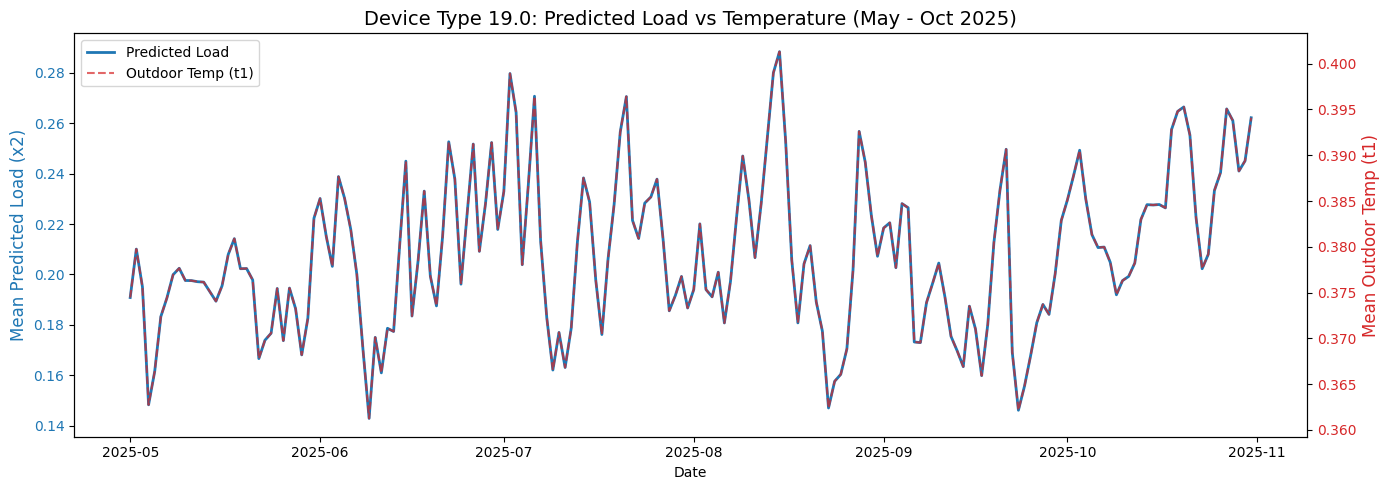

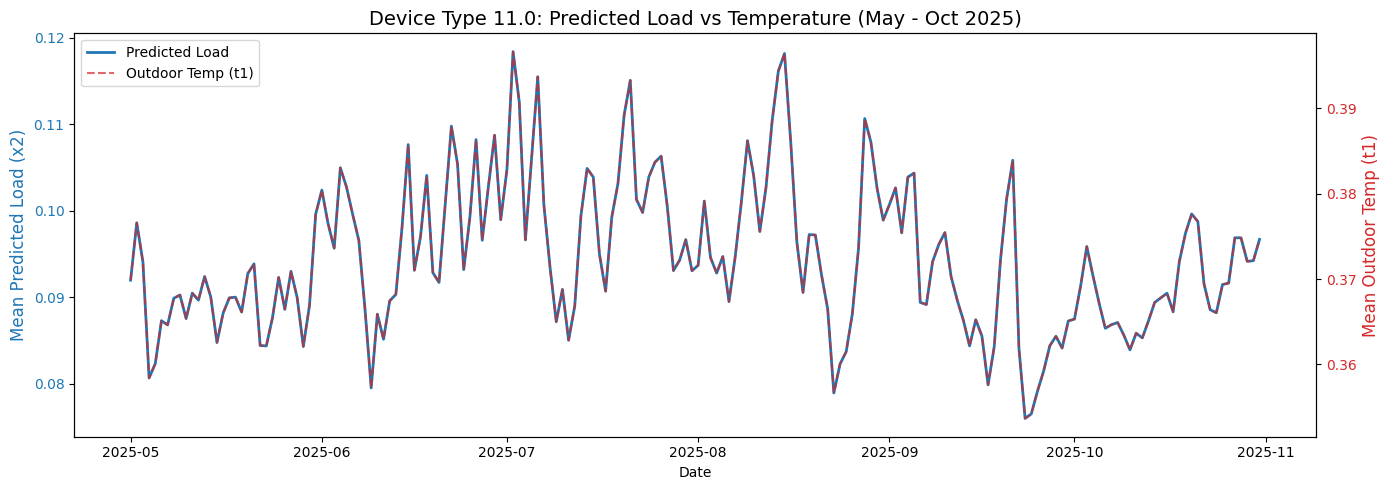

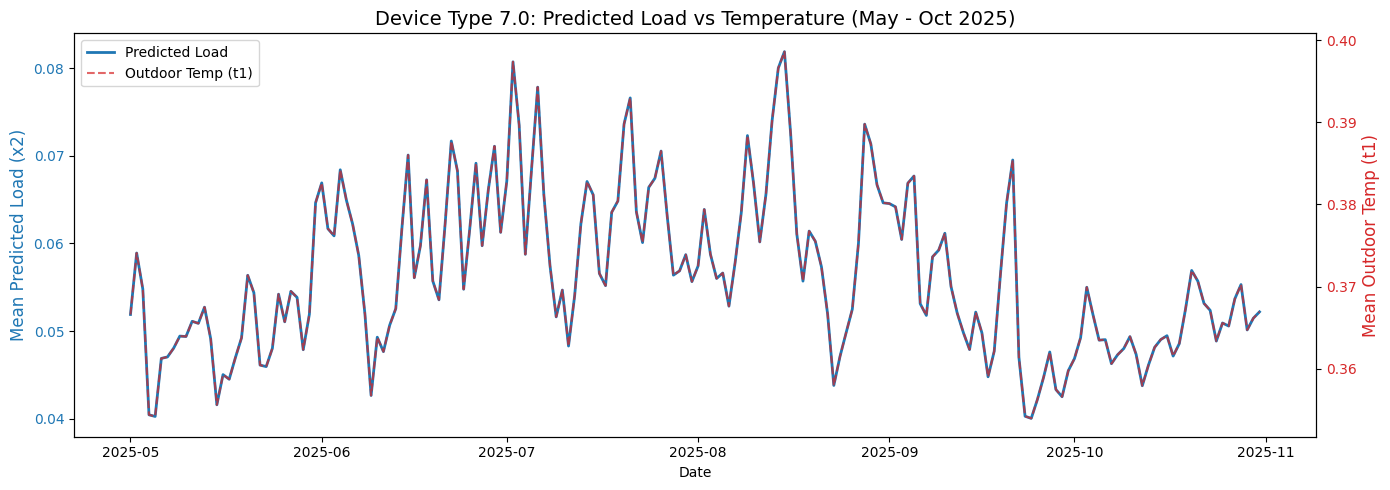

In [96]:
import matplotlib.pyplot as plt

# 1. Filter to the relevant submission window
plot_df = pred_clean[
    (pred_clean["year"] == 2025) & (pred_clean["month"].between(5, 10))
].copy()

tested_t = "t4"

# 2. Iterate through each device type
for d_type in plot_df['deviceType'].unique():
    # Group by date to get the average behavior of all devices of this type
    type_subset = plot_df[plot_df['deviceType'] == d_type]
    daily_avg = type_subset.groupby('date')[['daily_x2_pred', tested_t]].mean().reset_index()
    daily_avg = daily_avg.sort_values('date')

    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Plot Predicted Load on the left Y-axis
    color_load = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Mean Predicted Load (x2)', color=color_load, fontsize=12)
    ax1.plot(daily_avg['date'], daily_avg['daily_x2_pred'], color=color_load, linewidth=2, label='Predicted Load')
    ax1.tick_params(axis='y', labelcolor=color_load)

    # Create a second Y-axis for Temperature
    ax2 = ax1.twinx()
    color_temp = 'tab:red'
    ax2.set_ylabel('Mean Outdoor Temp (t1)', color=color_temp, fontsize=12)
    ax2.plot(daily_avg['date'], daily_avg[tested_t], color=color_temp, linewidth=1.5, linestyle='--', alpha=0.7, label='Outdoor Temp (t1)')
    ax2.tick_params(axis='y', labelcolor=color_temp)

    # Title and Legend
    plt.title(f"Device Type {d_type}: Predicted Load vs Temperature (May - Oct 2025)", fontsize=14)

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

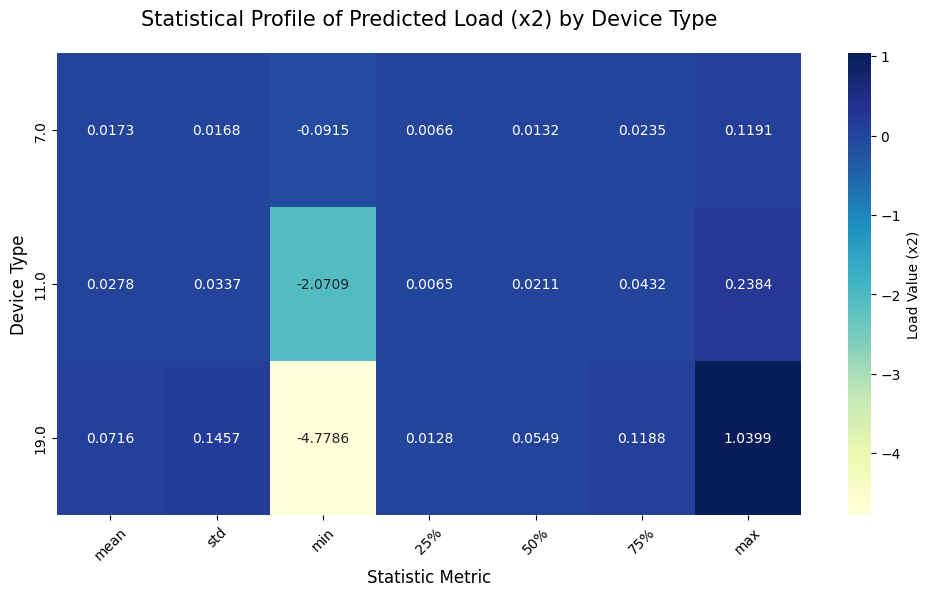

Full Summary Table (including Counts):


,deviceType,count,mean,std,min,25%,50%,75%,max
0,7.000000,10472.000000,0.017295,0.016831,-0.091525,0.006576,0.013153,0.023531,0.119143
1,11.000000,64836.000000,0.027837,0.033665,-2.070867,0.006516,0.021140,0.043238,0.238418
2,19.000000,30221.000000,0.071595,0.145727,-4.778573,0.012756,0.054912,0.118819,1.039947


In [201]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate describe() for the predicted load, grouped by device type
stats_df = (
    pred_clean.groupby("deviceType")["daily_x2_pred"]
    .describe()
    .reset_index()
)

# 2. Prepare data for the heatmap (dropping 'count' to normalize the color scale)
heatmap_data = stats_df.set_index("deviceType").drop(columns=["count"])

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Load Value (x2)'}
)

plt.title("Statistical Profile of Predicted Load (x2) by Device Type", fontsize=15, pad=20)
plt.ylabel("Device Type", fontsize=12)
plt.xlabel("Statistic Metric", fontsize=12)
plt.xticks(rotation=45)

plt.show()

# 4. Display the raw table for precision
print("Full Summary Table (including Counts):")
display(stats_df.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'max']))